# Notebook 02 — Long-range social pressure, correlated duplex

**Goal:** Study the effect of vigilance range L ∈ {1, 2, 3, 4} when the game layer and the
vigilance layer are the same network (maximally correlated duplex). The influence of vigilant
nodes decays geometrically with distance: α_l ∝ λ^(l−1), λ = 0.5.

Networks: BA and ER, z = 4 and z = 16.  
Update rule: Fermi (K = 0.1).  
Parameters: b ∈ [1.0, 2.0], θ ∈ [0.0, 1.0], N = 1000, 100 replications.

**Structure:**
- **Part I — Simulation:** runs sweeps, saves to `data/02-*.csv`. Run once.
- **Part II — Figures:** loads CSVs, makes all plots independently.

In [1]:
# ── Shared: imports and parameters ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import model

N        = 1000
n_rep    = 100
L_VALUES = [1, 2, 3, 4]
lam      = 0.5
K_fermi  = 0.1
b_vals   = np.round(np.linspace(1.0, 2.0, 11), 2)
th_vals  = np.round(np.linspace(0.0, 1.0, 11), 2)
NET_SEED = 0
SIM_SEED = 0
N_JOBS   = -1

NETWORKS = [
    ('BA_z4',  'BA', 4,  r'BA, $z=4$'),
    ('BA_z16', 'BA', 16, r'BA, $z=16$'),
    ('ER_z4',  'ER', 4,  r'ER, $z=4$'),
    ('ER_z16', 'ER', 16, r'ER, $z=16$'),
]

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('b:', b_vals)
print('θ:', th_vals)

b: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
θ: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Part I — Simulation
*Run once. Each (network, L) pair saved separately; completed runs skipped automatically.*

In [2]:
# ── Build networks ──────────────────────────────────────────────────────────
graphs = {
    key: model.build_network(topo, N, z, seed=NET_SEED)
    for key, topo, z, _ in NETWORKS
}

for key, topo, z, label in NETWORKS:
    G = graphs[key]
    k = 2 * G.number_of_edges() / G.number_of_nodes()
    d = nx.diameter(G)
    print(f"{label:14s}  N={G.number_of_nodes()}  <k>={k:.2f}  diameter={d}")

BA, $z=4$       N=1000  <k>=3.99  diameter=7
BA, $z=16$      N=1000  <k>=15.87  diameter=4


ER, $z=4$       N=979  <k>=4.11  diameter=10
ER, $z=16$      N=1000  <k>=16.21  diameter=4


In [3]:
# ── Pre-compile JIT kernels ─────────────────────────────────────────────────
model.warm_up()
print('JIT kernels compiled.')

JIT kernels compiled.


In [4]:
# ── Run sweeps (correlated: G_vig = G_game) ─────────────────────────────────
# Note: for L=4 on dense networks the vigilance shells may encompass most of
# the network (mean-field limit). This is a scientific result, not a problem.

for key, topo, z, label in NETWORKS:
    G      = graphs[key]
    gp, gd = model.game_csr(G)   # game layer CSR (fixed for all L)
    for L in L_VALUES:
        path = f"data/02-{key}-L{L}.csv"
        if os.path.exists(path):
            print(f"  skip: {path}")
            continue
        print(f"  running {label}  L={L} ...", flush=True)
        sp, sd = model.shells_csr(G, L)   # vigilance shells (same network)
        al     = model.geometric_kernel(L, lam)
        df = model.run_sweep(
            gp, gd, sp, sd, al,
            b_vals, th_vals,
            K=K_fermi, n_rep=n_rep,
            n_jobs=N_JOBS, base_seed=SIM_SEED,
            update_rule='fermi',
        )
        df.to_csv(path, index=False)
        print(f"  saved: {path}")

print('Part I done.')

  skip: data/02-BA_z4-L1.csv
  skip: data/02-BA_z4-L2.csv
  skip: data/02-BA_z4-L3.csv
  skip: data/02-BA_z4-L4.csv
  skip: data/02-BA_z16-L1.csv
  skip: data/02-BA_z16-L2.csv
  skip: data/02-BA_z16-L3.csv
  skip: data/02-BA_z16-L4.csv
  skip: data/02-ER_z4-L1.csv
  skip: data/02-ER_z4-L2.csv
  skip: data/02-ER_z4-L3.csv
  skip: data/02-ER_z4-L4.csv
  skip: data/02-ER_z16-L1.csv
  skip: data/02-ER_z16-L2.csv
  skip: data/02-ER_z16-L3.csv
  skip: data/02-ER_z16-L4.csv
Part I done.


---
## Part II — Figures
*Loads CSVs from `data/` independently of Part I.*

In [5]:
# ── Load results ─────────────────────────────────────────────────────────────
data = {}
for key, topo, z, label in NETWORKS:
    for L in L_VALUES:
        path = f"data/02-{key}-L{L}.csv"
        data[(key, L)] = pd.read_csv(path)
        print(f"  loaded {path}")

  loaded data/02-BA_z4-L1.csv
  loaded data/02-BA_z4-L2.csv
  loaded data/02-BA_z4-L3.csv
  loaded data/02-BA_z4-L4.csv
  loaded data/02-BA_z16-L1.csv
  loaded data/02-BA_z16-L2.csv
  loaded data/02-BA_z16-L3.csv
  loaded data/02-BA_z16-L4.csv
  loaded data/02-ER_z4-L1.csv
  loaded data/02-ER_z4-L2.csv
  loaded data/02-ER_z4-L3.csv
  loaded data/02-ER_z4-L4.csv
  loaded data/02-ER_z16-L1.csv
  loaded data/02-ER_z16-L2.csv
  loaded data/02-ER_z16-L3.csv
  loaded data/02-ER_z16-L4.csv


In [6]:
# ── Figure settings ──────────────────────────────────────────────────────────
import matplotlib as mpl

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
})

# Sequential: GnBu — light green (low) → dark navy (high)
CMAP = 'GnBu'
# Diverging: standard red-blue -- red (loss) -> white (zero) -> blue (gain)
CMAP_DIFF = 'RdBu'  # red=decrease, blue=increase -- standard diverging map
VMIN, VMAX = 0.0, 1.0
VDIFF      = 0.4

THETA_SHOW = [0.3, 0.5, 0.7]

# Dark2 (ColorBrewer) — first 4 colors
_d2      = mpl.colormaps['Dark2']
DARK2    = {1: _d2(0), 2: _d2(1), 3: _d2(2), 4: _d2(3)}
L_STYLES = {1: '-',   2: '--',   3: '-.',   4: ':'}
LW       = 2.0

db, dt = b_vals[1] - b_vals[0], th_vals[1] - th_vals[0]
EXTENT = [b_vals[0]-db/2, b_vals[-1]+db/2, th_vals[0]-dt/2, th_vals[-1]+dt/2]

def rho_matrix(df):
    return (
        df.pivot(index='theta', columns='b', values='rho_mean')
          .sort_index(ascending=True)
          .values
    )

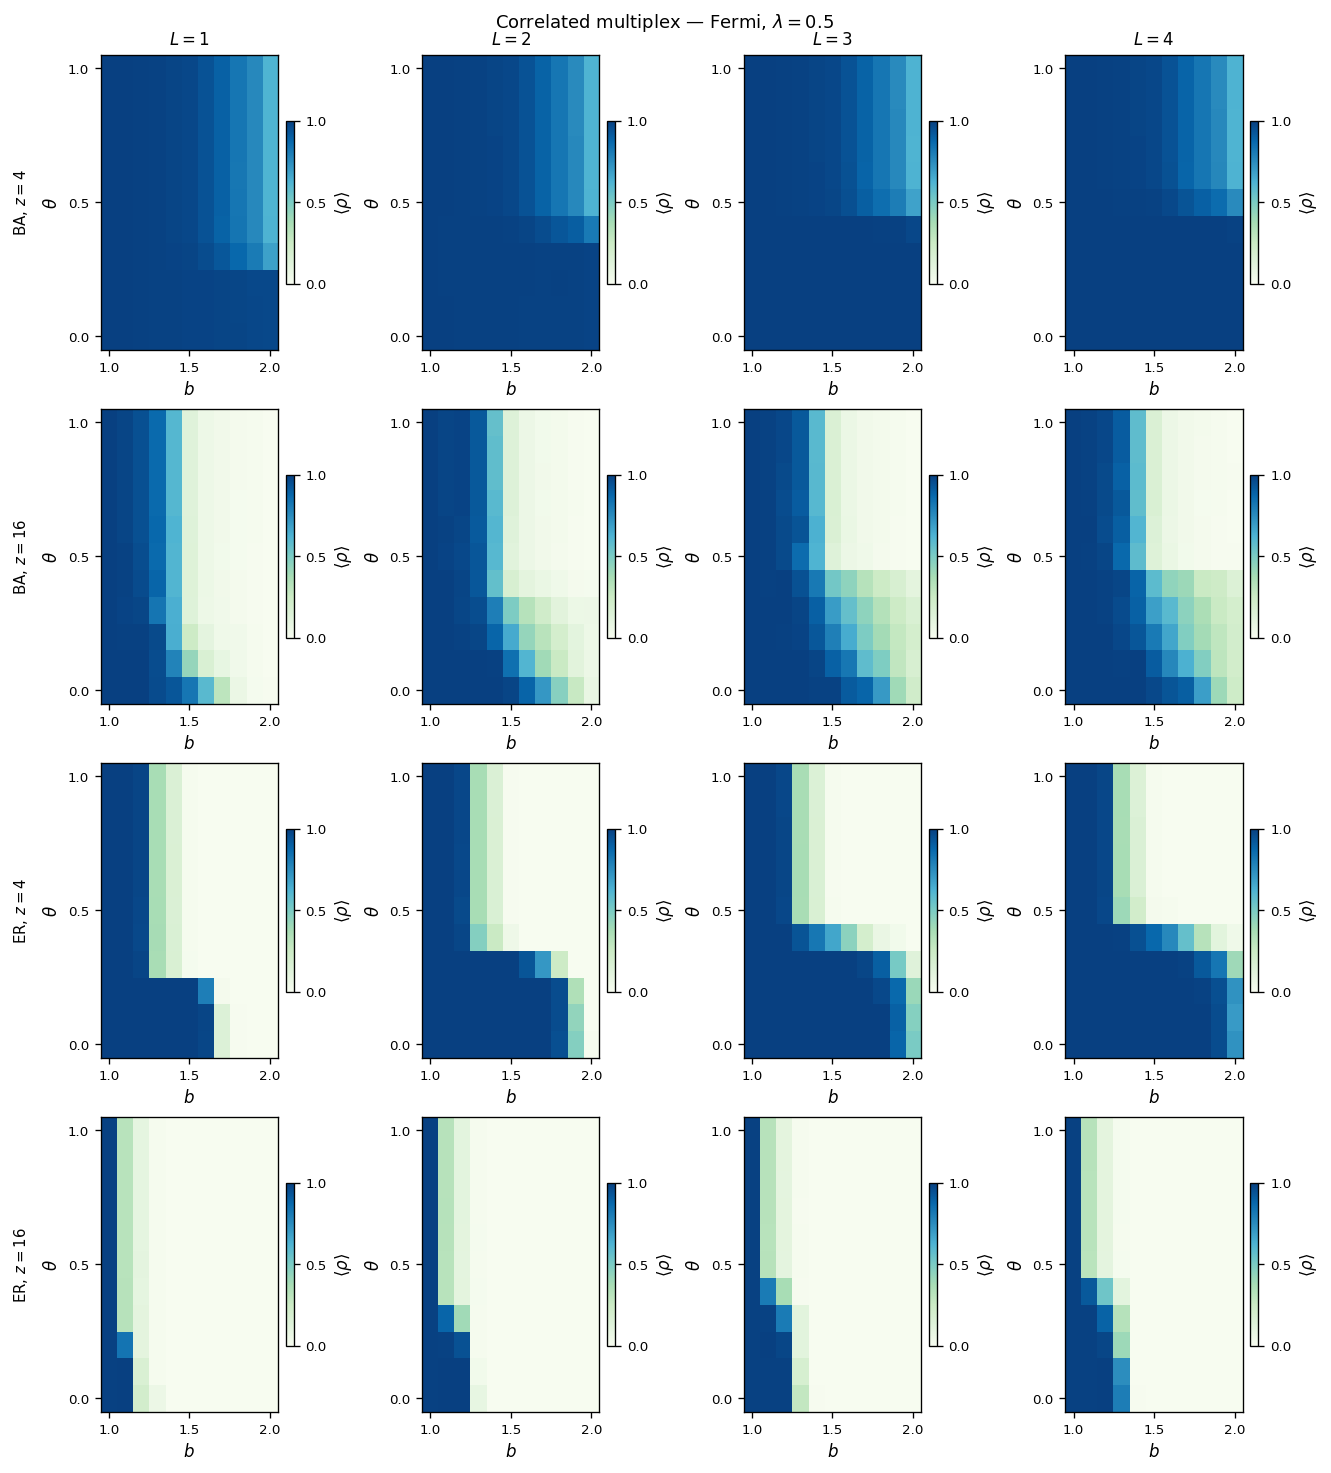

Saved figures/02-heatmaps.pdf


In [7]:
# ── Figure 1: heatmaps rho(b,θ) — rows = networks, cols = L ──────────────────
fig1, axes = plt.subplots(
    len(NETWORKS), len(L_VALUES),
    figsize=(11, 12),
    constrained_layout=True,
)

for row, (key, topo, z, label) in enumerate(NETWORKS):
    for col, L in enumerate(L_VALUES):
        ax  = axes[row, col]
        mat = rho_matrix(data[(key, L)])
        im  = ax.imshow(
            mat, origin='lower', aspect='auto',
            vmin=VMIN, vmax=VMAX, cmap=CMAP, extent=EXTENT,
        )
        ax.set_xlabel('$b$')
        ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0:
            ax.set_title(f'$L={L}$', fontweight='bold')
        if col == 0:
            ax.text(-0.45, 0.5, label, transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)
        cb = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\langle\rho\rangle$')
        cb.set_ticks([0, 0.5, 1.0])

fig1.suptitle('Correlated multiplex — Fermi, $\\lambda=0.5$', y=1.01)
fig1.savefig('figures/02-heatmaps.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/02-heatmaps.pdf')

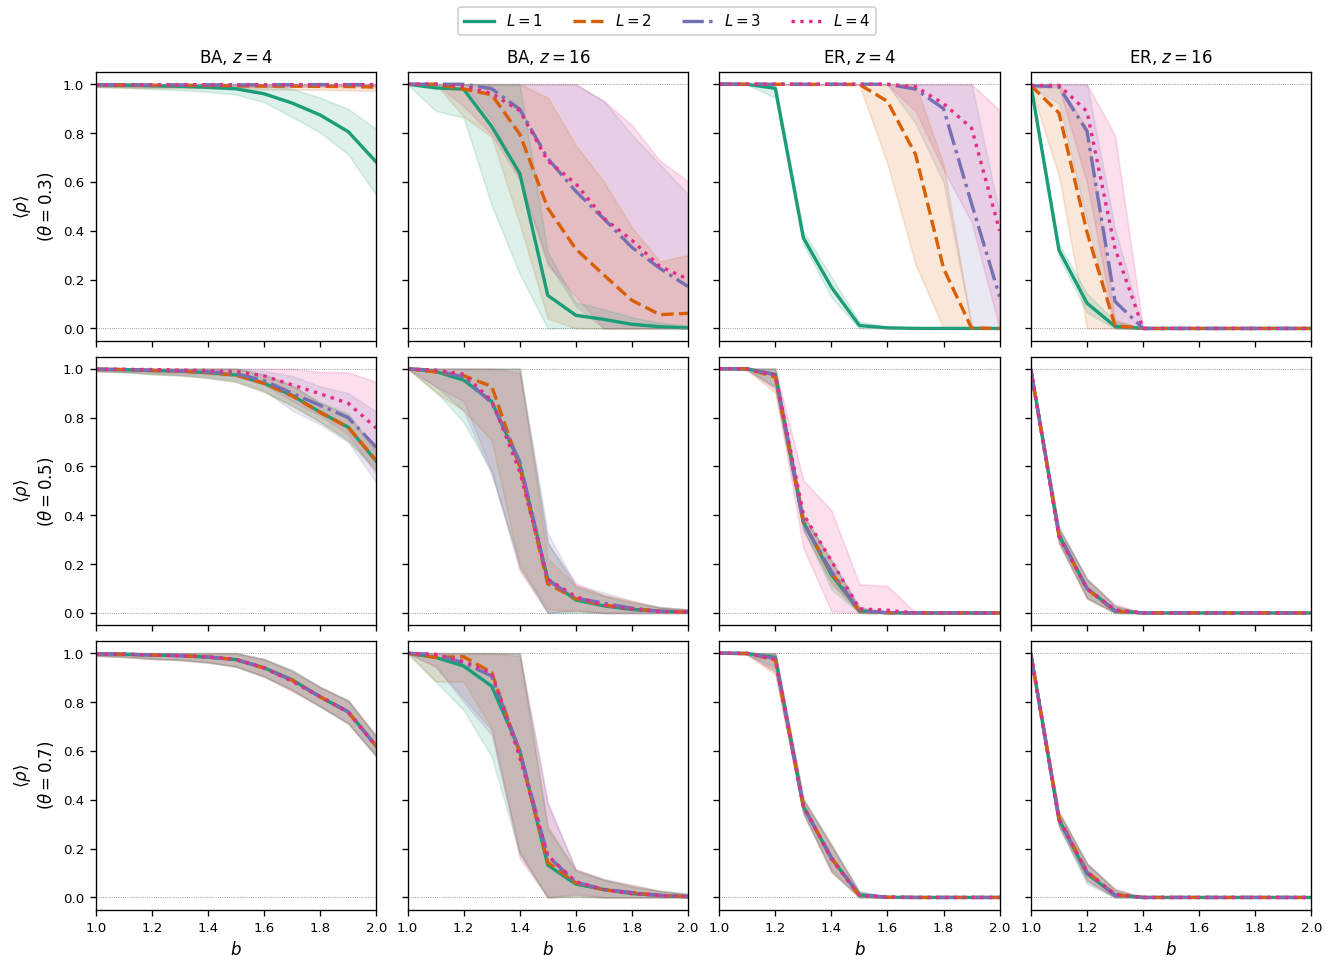

Saved figures/02-marginals.pdf


In [8]:
# ── Figure 2: marginals rho vs b at selected θ values ────────────────────────
fig2, axes2 = plt.subplots(
    len(THETA_SHOW), len(NETWORKS),
    figsize=(11, 8),
    constrained_layout=True,
    sharey=True, sharex=True,
)

for col, (key, topo, z, label) in enumerate(NETWORKS):
    for row, th in enumerate(THETA_SHOW):
        ax = axes2[row, col]
        # fills in reverse L order so L=1 (green) sits on top
        for L in reversed(L_VALUES):
            df  = data[(key, L)]
            sub = df[np.isclose(df['theta'], th)].sort_values('b')
            ax.fill_between(
                sub['b'],
                (sub['rho_mean'] - sub['rho_std']).clip(0),
                (sub['rho_mean'] + sub['rho_std']).clip(0, 1),
                alpha=0.15, color=DARK2[L],
            )
        # lines on top of all fills
        for L in L_VALUES:
            df  = data[(key, L)]
            sub = df[np.isclose(df['theta'], th)].sort_values('b')
            ax.plot(
                sub['b'], sub['rho_mean'],
                color=DARK2[L], linestyle=L_STYLES[L],
                label=f'$L={L}$', lw=LW,
            )
        if row == 0:
            ax.set_title(label)
        if col == 0:
            ax.set_ylabel(f'$\\langle\\rho\\rangle$\n($\\theta={th}$)')
        if row == len(THETA_SHOW) - 1:
            ax.set_xlabel('$b$')
        ax.set_xlim(1.0, 2.0)
        ax.set_ylim(-0.05, 1.05)
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.axhline(1, color='grey', lw=0.5, ls=':')

handles, labels = axes2[0, 0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='outside upper center',
            ncol=len(L_VALUES), fontsize=9, framealpha=0.9)
fig2.savefig('figures/02-marginals.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/02-marginals.pdf')

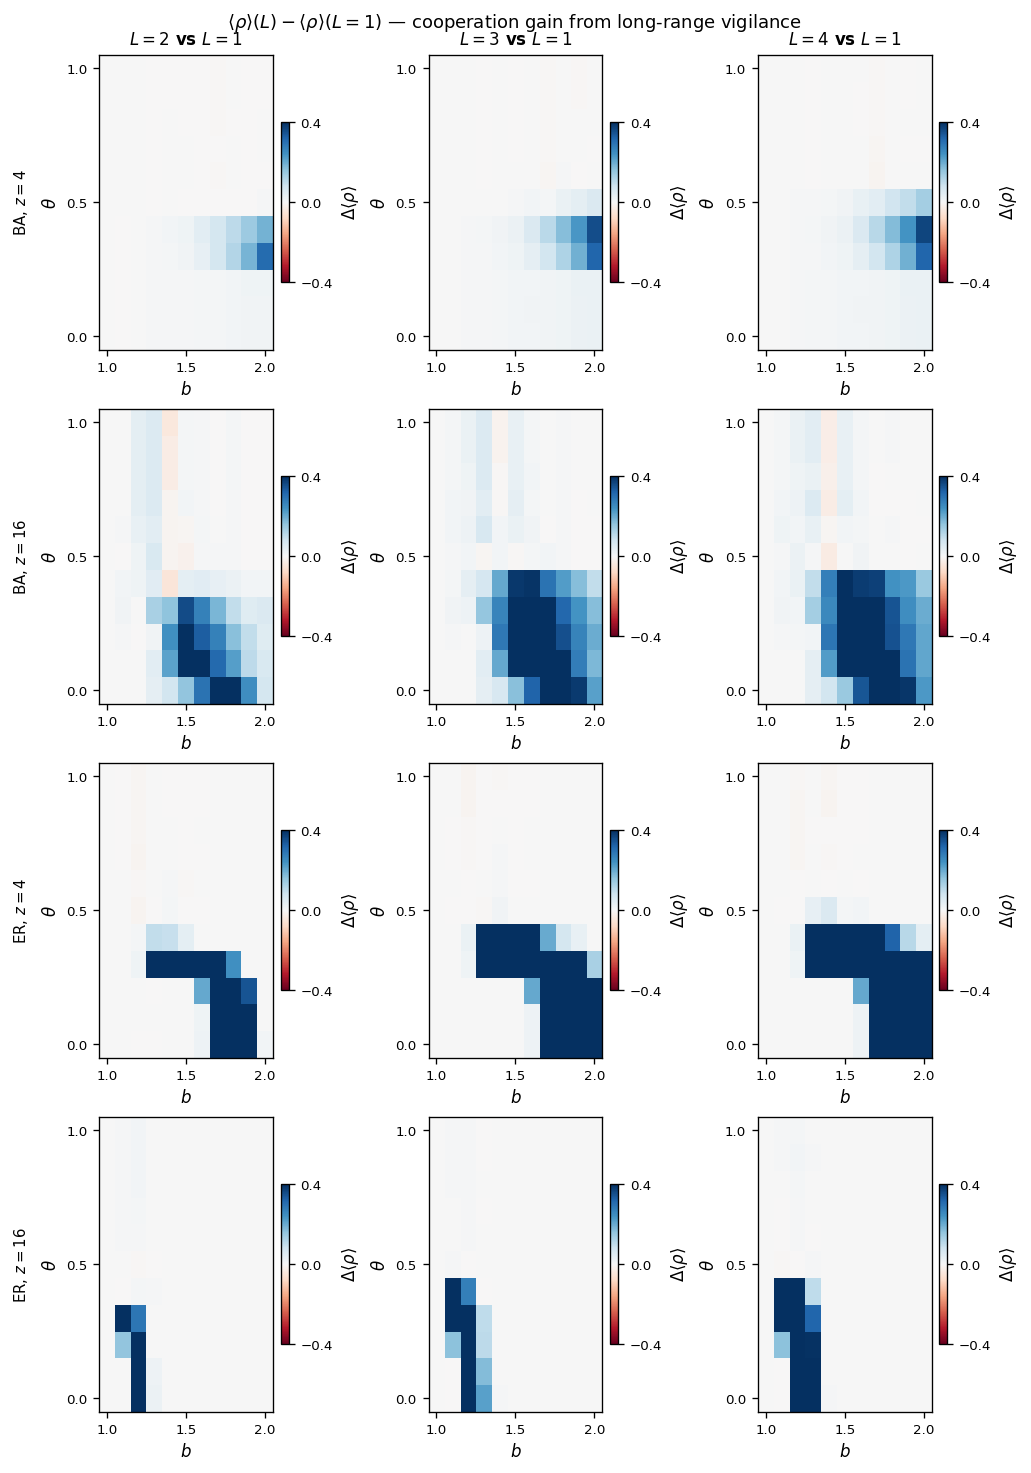

Saved figures/02-difference.pdf


In [9]:
# -- Figure 3 / S5: CUMULATIVE difference maps rho(L) - rho(L=1) --
# Baseline-referenced total gain, all four topologies (Supplemental Material Fig. S5).
# The human-readable MARGINAL version (rho(L) - rho(L-1), ER z=4 only) is Fig. 4 of
# the main text -- see the next cell.
L_DIFF = [2, 3, 4]

fig3, axes3 = plt.subplots(
    len(NETWORKS), len(L_DIFF),
    figsize=(8.5, 12),
    constrained_layout=True,
)

for row, (key, topo, z, label) in enumerate(NETWORKS):
    base = rho_matrix(data[(key, 1)])
    for col, L in enumerate(L_DIFF):
        ax   = axes3[row, col]
        diff = rho_matrix(data[(key, L)]) - base
        im   = ax.imshow(
            diff, origin='lower', aspect='auto',
            vmin=-VDIFF, vmax=VDIFF, cmap=CMAP_DIFF, extent=EXTENT,
        )
        ax.set_xlabel('$b$')
        ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0:
            ax.set_title(f'$L={L}$ vs $L=1$', fontweight='bold')
        if col == 0:
            ax.text(-0.45, 0.5, label, transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)
        cb = fig3.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\Delta\langle\rho\rangle$')
        cb.set_ticks([-VDIFF, 0, VDIFF])

fig3.suptitle(
    r'$\langle\rho\rangle(L) - \langle\rho\rangle(L=1)$'
    ' — cooperation gain from long-range vigilance', y=1.01,
)
fig3.savefig('figures/02-difference.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/02-difference.pdf')

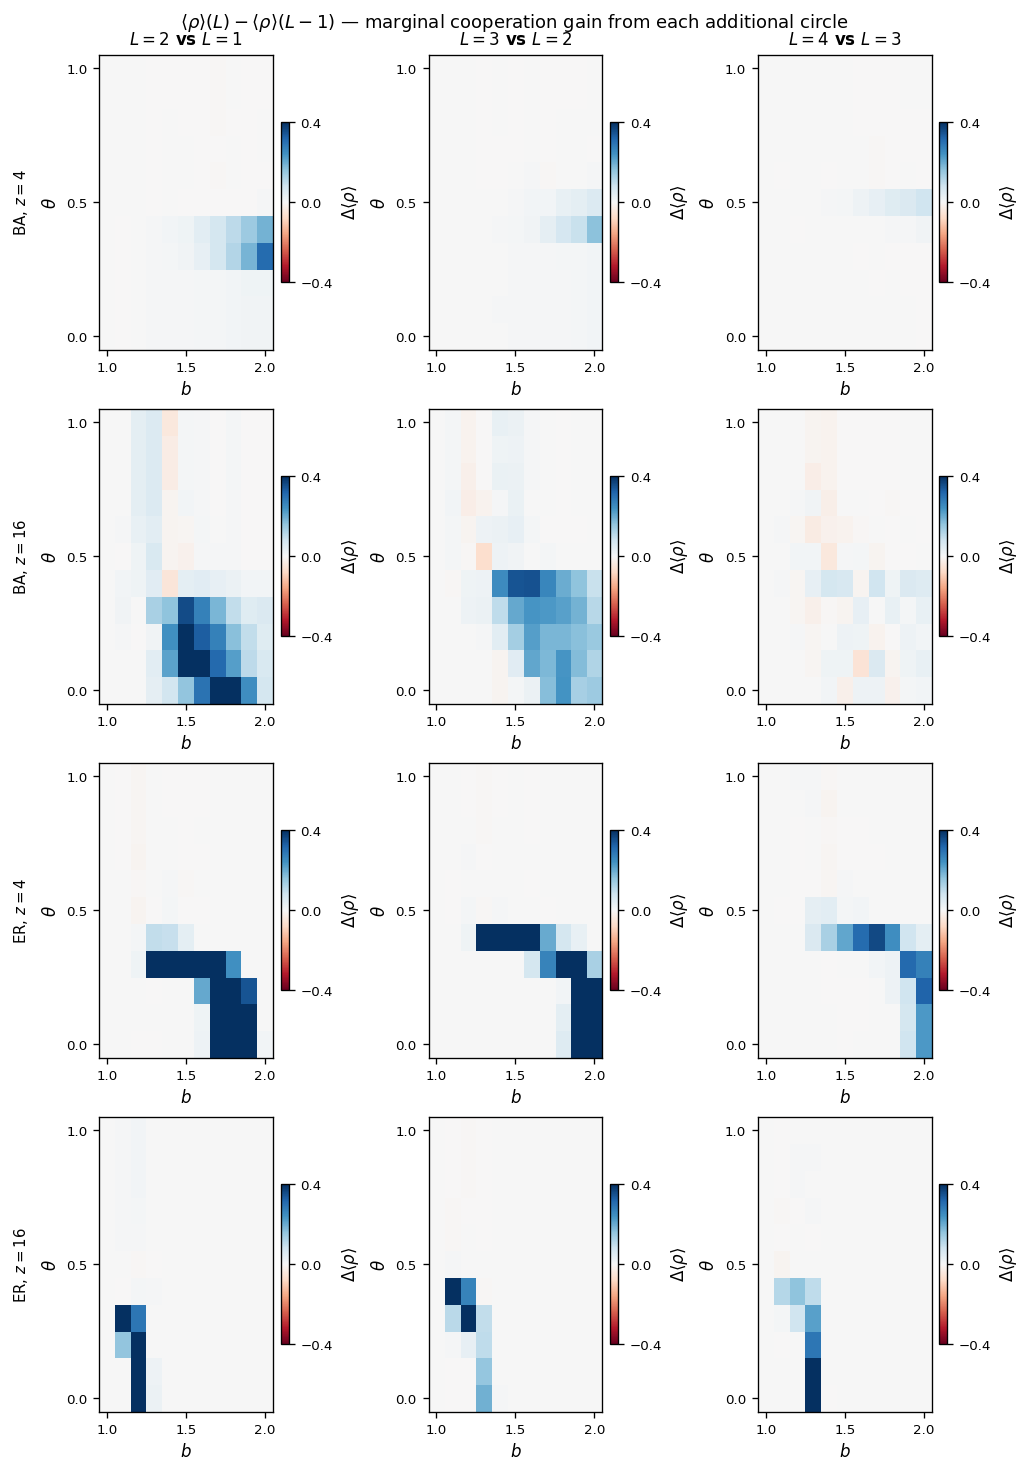

Saved figures/02-difference-marginal.pdf


In [10]:
# -- Figure S5b: MARGINAL difference maps rho(L) - rho(L-1), all four topologies --
# Extends Fig. 4 of the main text (ER z=4 only) to all topologies.
L_DIFF = [2, 3, 4]

fig3b, axes3b = plt.subplots(
    len(NETWORKS), len(L_DIFF),
    figsize=(8.5, 12),
    constrained_layout=True,
)

for row, (key, topo, z, label) in enumerate(NETWORKS):
    for col, L in enumerate(L_DIFF):
        ax   = axes3b[row, col]
        diff = rho_matrix(data[(key, L)]) - rho_matrix(data[(key, L - 1)])
        im   = ax.imshow(
            diff, origin='lower', aspect='auto',
            vmin=-VDIFF, vmax=VDIFF, cmap=CMAP_DIFF, extent=EXTENT,
        )
        ax.set_xlabel('$b$')
        ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0:
            ax.set_title(f'$L={L}$ vs $L={L-1}$', fontweight='bold')
        if col == 0:
            ax.text(-0.45, 0.5, label, transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)
        cb = fig3b.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\Delta\langle\rho\rangle$')
        cb.set_ticks([-VDIFF, 0, VDIFF])

fig3b.suptitle(
    r'$\langle\rho\rangle(L) - \langle\rho\rangle(L-1)$'
    ' — marginal cooperation gain from each additional circle', y=1.01,
)
fig3b.savefig('figures/02-difference-marginal.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/02-difference-marginal.pdf')

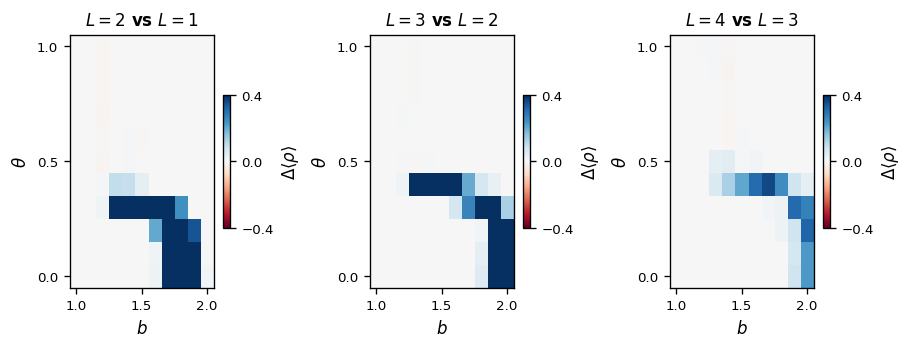

Saved figures/02-difference-ER4.pdf


In [11]:
# -- Figure 4: MARGINAL difference map -- ER z=4 only (paper main figure) --
# rho(L) - rho(L-1): what each additional circle buys, ER z=4.
# Full grid (all 4 networks) is Fig. S5 in the Supplemental Material.
L_DIFF   = [2, 3, 4]

fig4, axes4 = plt.subplots(1, 3, figsize=(7.5, 2.8), constrained_layout=True)
for ax, L in zip(axes4, L_DIFF):
    diff = rho_matrix(data[('ER_z4', L)]) - rho_matrix(data[('ER_z4', L - 1)])
    im = ax.imshow(diff, origin='lower', aspect='auto',
                   vmin=-VDIFF, vmax=VDIFF, cmap=CMAP_DIFF, extent=EXTENT)
    ax.set_xlabel('$b$'); ax.set_ylabel(r'$\theta$')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.set_title(f'$L={L}$ vs $L={L-1}$', fontweight='bold')
    cb = fig4.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(r'$\Delta\langle\rho\rangle$')
    cb.set_ticks([-VDIFF, 0, VDIFF])

fig4.savefig('figures/02-difference-ER4.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/02-difference-ER4.pdf')